# Local error distribution study — WEB-spline transform solver

This notebook examines the local error distribution of the WEB-spline transform
solver (Höllig coupling-matrix method) for various polygon geometries, using
the same testcases as the collocation error study.

**Solver workflow** (from `main.py`, `USE_WEB_TRANSFORM` path):
1. Standard weighted B-spline assembly (`FEM.processAllElements`)
2. WEB coupling-matrix transform, $\hat{K} = \tilde{E} K \tilde{E}^T$ (`FEM_WEB.transformStandardSystemToWEB`)
3. Solve reduced system (`FEM_WEB.solveWEB`)
4. Point-by-point solution reconstruction (`FEM_WEB.reconstructSolution`)

**Manufactured solution:** $u = w^2$ where $w$ is the weight (R-function) for the geometry.

**Sweep parameters:**
- B-spline degree (order): 2, 3, 4
- Mesh divisions: 8, 16, 32
- `MAX_SUBDIVISION` (boundary element quadrature refinement): 0, 2

In [1]:
import os, sys, time
from dataclasses import dataclass
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from scipy import sparse

NA_DIR = os.path.join(os.getcwd(), "Neural Analysis")
if NA_DIR not in sys.path:
    sys.path.insert(0, NA_DIR)

import FEM
import FEM_WEB
import mesh
import Geomertry as geom

import importlib
importlib.reload(geom)
importlib.reload(mesh)
importlib.reload(FEM)
importlib.reload(FEM_WEB)

plt.rcParams.update({"figure.dpi": 150})

# Reproducibility
np.random.seed(0)
torch.manual_seed(0)

# Toggle for quick validation
SMOKE = False

# Grid resolution for heatmap (per axis)
HEATMAP_N = 50 if not SMOKE else 20
# Random interior points for error analysis
N_RANDOM_EVAL = 2000 if not SMOKE else 200
CONTOUR_LEVELS = 80
DELTA = 0.005  # mesh extension beyond physical domain

# --------------- Geometry variants ---------------
DOMAIN_M11 = {"x1": -1.0, "x2": 1.0, "y1": -1.0, "y2": 1.0}

TRI_VERTS = np.array([[-0.85, -0.60], [0.90, -0.55], [0.05, 0.92]], dtype=np.float64)
TRI_VERTS_R90 = TRI_VERTS @ np.array([[0.0, -1.0], [1.0, 0.0]], dtype=np.float64).T


@dataclass(frozen=True)
class GeometryVariant:
    name: str
    model: torch.nn.Module
    domain: Dict[str, float]


GEOMS: List[GeometryVariant] = [
    GeometryVariant(
        name="triangle R-func",
        model=geom.AnaliticalDistanceTriangle_RFunction(preserve_zero_line=True, vertices=TRI_VERTS),
        domain=DOMAIN_M11,
    ),
    GeometryVariant(
        name="triangle 90\u00b0 R-func",
        model=geom.AnaliticalDistanceTriangle_RFunction(preserve_zero_line=True, vertices=TRI_VERTS_R90),
        domain=DOMAIN_M11,
    ),
    GeometryVariant(
        name="pentagon R-func",
        model=geom.AnaliticalDistancePentagon_RFunction(preserve_zero_line=True),
        domain=DOMAIN_M11,
    ),
]

# --------------- Sweep parameters ---------------
if SMOKE:
    DEGREES = [2, 3]
    DIVISIONS_LIST = [8, 16]
    MAX_SUBDIVISIONS = [0, 2]
else:
    DEGREES = [2, 3]
    DIVISIONS_LIST = [30, 50, 80]
    MAX_SUBDIVISIONS = [0, 2, 4]


# --------------- Helper functions ---------------
def compute_near_boundary_binning(
    sdf_inside: np.ndarray,
    err_inside: np.ndarray,
    n_bins: int = 30,
    w_max: Optional[float] = None,
) -> pd.DataFrame:
    """Bin errors by SDF distance from boundary."""
    sdf_inside = np.asarray(sdf_inside, dtype=np.float64).ravel()
    err_inside = np.asarray(err_inside, dtype=np.float64).ravel()
    mask = np.isfinite(sdf_inside) & np.isfinite(err_inside)
    sdf_inside, err_inside = sdf_inside[mask], err_inside[mask]
    if sdf_inside.size == 0:
        return pd.DataFrame({"sdf_mid": [], "err_mean": [], "count": []})
    if w_max is None:
        w_max = float(np.quantile(sdf_inside, 0.995))
    w_max = max(w_max, 1e-12)
    edges = np.linspace(0.0, w_max, n_bins + 1)
    rows = []
    for i in range(n_bins):
        a, b = edges[i], edges[i + 1]
        sel = (sdf_inside >= a) & (sdf_inside < b)
        if not np.any(sel):
            continue
        rows.append({
            "sdf_mid": 0.5 * (a + b),
            "err_mean": float(np.mean(err_inside[sel])),
            "count": int(np.sum(sel)),
        })
    return pd.DataFrame(rows)


def sample_interior_points(model, verts_np, n_points, rng=None):
    """Rejection-sample random points inside a convex polygon."""
    if rng is None:
        rng = np.random.default_rng(42)
    xmin, xmax = float(verts_np[:, 0].min()), float(verts_np[:, 0].max())
    ymin, ymax = float(verts_np[:, 1].min()), float(verts_np[:, 1].max())
    pts_x, pts_y = [], []
    while len(pts_x) < n_points:
        batch = max(n_points * 3, 5000)
        rx = rng.uniform(xmin, xmax, size=batch)
        ry = rng.uniform(ymin, ymax, size=batch)
        crd = torch.tensor(np.stack([rx, ry], axis=-1), dtype=torch.float64)
        verts_t = crd.new_tensor(verts_np)
        inside_mask = geom._point_in_convex_polygon_ccw(crd, verts_t).numpy()
        pts_x.append(rx[inside_mask])
        pts_y.append(ry[inside_mask])
    pts_x = np.concatenate(pts_x)[:n_points]
    pts_y = np.concatenate(pts_y)[:n_points]
    return pts_x, pts_y

In [2]:
def run_one_web(
    geom_variant: GeometryVariant,
    order: int,
    divisions: int,
    max_subdivision: int,
    n_eval: int = N_RANDOM_EVAL,
    heatmap_n: int = 0,
    delta: float = DELTA,
) -> dict:
    """Run WEB-spline transform solver and return error analysis results.

    Parameters
    ----------
    geom_variant : GeometryVariant
        Geometry definition (model + domain).
    order : int
        B-spline degree p (== q).
    divisions : int
        Number of mesh divisions in each direction.
    max_subdivision : int
        MAX_SUBDIVISION for boundary element quadrature (0 or 2).
    n_eval : int
        Number of random interior points for error analysis.
    heatmap_n : int
        Grid resolution for heatmap (0 = skip heatmap).
    delta : float
        Mesh extension beyond physical domain.
    """
    model = geom_variant.model
    verts_np = model._vertices_np

    # --------------- Set FEM globals ---------------
    FEM.set_function_case(9)  # manufactured u = w**2
    FEM.MAX_SUBDIVISION = max_subdivision
    FEM.ACTIVE_MODEL = model
    mesh.TRANSFORM = None  # R-function models already smooth

    # Clear caches (knot vectors change between runs)
    FEM._BSPLINE_CACHE.clear()
    FEM._ASSEMBLY_INDEX_CACHE.clear()
    FEM._ZERO_CACHE.clear()

    p = q = order

    # --------------- Create mesh ---------------
    default = mesh.getDefaultValues(div=divisions, order=order, delta=delta)
    x0, y0, x1, y1, xDivision, yDivision, _, _ = default
    knotvector_u, knotvector_w, _, _ = mesh.generateRectangularMesh(*default)

    x_init = np.linspace(x0, x1, 10)
    geom.init_spl(x_init, p, None, knotvector_u)

    # --------------- Standard weighted B-spline assembly ---------------
    matrix_size = (xDivision + p + 1) * (yDivision + q + 1)
    K = sparse.lil_matrix((matrix_size, matrix_size), dtype=np.float64)
    F = np.zeros(matrix_size, dtype=np.float64)

    K, F, etype_std = FEM.processAllElements(
        model, p, q, knotvector_u, knotvector_w, xDivision, yDivision, K, F,
    )

    # --------------- WEB coupling-matrix transform ---------------
    K_web, F_web, etype, bsp_class, ext_basis, E_tilde = FEM_WEB.transformStandardSystemToWEB(
        K, F, model, p, q, knotvector_u, knotvector_w, xDivision, yDivision,
        web_use_weight_normalization=True,
        web_ref_weight_eps=1e-6,
        extension_method="collocation",
    )

    # --------------- Solve ---------------
    result = FEM_WEB.solveWEB(K_web, F_web)
    n_dofs = len(result)

    # --------------- Evaluate at random interior points ---------------
    rng = np.random.default_rng(42)
    pts_x, pts_y = sample_interior_points(model, verts_np, n_eval, rng=rng)

    u_h = np.zeros(n_eval, dtype=np.float64)
    for i in range(n_eval):
        u_h[i] = FEM_WEB.reconstructSolution(
            pts_x[i], pts_y[i], result, model, p, q,
            knotvector_u, knotvector_w, bsp_class, ext_basis,
        )

    # Exact solution u = w**2 (via FEM.solution_function with ACTIVE_MODEL)
    u_ex = np.array([FEM.solution_function(pts_x[i], pts_y[i]) for i in range(n_eval)])
    err = np.abs(u_h - u_ex)

    # True SDF for near-boundary binning
    with torch.no_grad():
        crd_eval = torch.tensor(np.stack([pts_x, pts_y], axis=-1), dtype=torch.float64)
        verts_t = crd_eval.new_tensor(verts_np)
        sdf_eval = geom.convex_polygon_sdf(crd_eval, verts_t).numpy()

    bins = compute_near_boundary_binning(sdf_eval, err, n_bins=30)

    # --------------- Optional heatmap grid ---------------
    heatmap_data = None
    if heatmap_n > 0:
        xmin_v, xmax_v = float(verts_np[:, 0].min()), float(verts_np[:, 0].max())
        ymin_v, ymax_v = float(verts_np[:, 1].min()), float(verts_np[:, 1].max())
        hm_x = np.linspace(xmin_v - 0.05, xmax_v + 0.05, heatmap_n)
        hm_y = np.linspace(ymin_v - 0.05, ymax_v + 0.05, heatmap_n)
        HX, HY = np.meshgrid(hm_x, hm_y)
        HU = np.full_like(HX, np.nan)
        HUex = np.full_like(HX, np.nan)
        for ix in range(heatmap_n):
            for iy in range(heatmap_n):
                xx, yy = hm_x[ix], hm_y[iy]
                d_val = mesh.distanceFromContur(xx, yy, model)
                if hasattr(d_val, "item"):
                    d_val = d_val.item()
                if d_val >= 0:
                    HU[iy, ix] = FEM_WEB.reconstructSolution(
                        xx, yy, result, model, p, q,
                        knotvector_u, knotvector_w, bsp_class, ext_basis,
                    )
                    HUex[iy, ix] = FEM.solution_function(xx, yy)
        heatmap_data = {"HX": HX, "HY": HY, "HU": HU, "HUex": HUex}

    summary = {
        "geom": geom_variant.name,
        "order": order,
        "div": divisions,
        "max_subdiv": max_subdivision,
        "n_dofs": n_dofs,
        "n_eval": n_eval,
        "err_mean": float(np.mean(err)),
        "err_max": float(np.max(err)),
        "err_median": float(np.median(err)),
    }

    # --- Solution state for later evaluation ---
    # With these objects one can call:
    #   FEM_WEB.reconstructSolution(x, y, sol_state["u_reduced"], model, p, q,
    #       sol_state["knotvector_u"], sol_state["knotvector_w"],
    #       sol_state["bsp_class"], sol_state["ext_basis"])
    # or the gradient / Hessian variants.
    sol_state = {
        "u_reduced": result,
        "model": model,
        "p": p,
        "q": q,
        "knotvector_u": knotvector_u,
        "knotvector_w": knotvector_w,
        "bsp_class": bsp_class,
        "ext_basis": ext_basis,
        "E_tilde": E_tilde,
    }

    return {
        "summary": summary,
        "sol_state": sol_state,
        "pts_x": pts_x,
        "pts_y": pts_y,
        "u_h": u_h,
        "u_ex": u_ex,
        "err": err,
        "sdf": sdf_eval,
        "bins": bins,
        "heatmap": heatmap_data,
    }

In [3]:
all_summaries = []
all_results = {}

for gv in GEOMS:
    for deg in DEGREES:
        for div in DIVISIONS_LIST:
            for msub in MAX_SUBDIVISIONS:
                key = (gv.name, deg, div, msub)
                print(f"\n{'='*60}")
                print(f"geom={gv.name} | order={deg} | div={div} | max_subdiv={msub}")
                print(f"{'='*60}")

                # Compute heatmap only for the first config of each geometry
                do_heatmap = (
                    deg == DEGREES[0]
                    and div == DIVISIONS_LIST[0]
                    and msub == MAX_SUBDIVISIONS[0]
                )

                t0 = time.time()
                res = run_one_web(
                    gv,
                    order=deg,
                    divisions=div,
                    max_subdivision=msub,
                    heatmap_n=HEATMAP_N if do_heatmap else 0,
                )
                elapsed = time.time() - t0

                res["summary"]["time_s"] = round(elapsed, 1)
                all_results[key] = res
                all_summaries.append(res["summary"])

                s = res["summary"]
                print(
                    f"  DOFs={s['n_dofs']}  err_max={s['err_max']:.3e}"
                    f"  err_mean={s['err_mean']:.3e}  ({elapsed:.1f}s)"
                )

summary_df = pd.DataFrame(all_summaries)
summary_df = summary_df.sort_values(
    ["geom", "order", "div", "max_subdiv"]
).reset_index(drop=True)
summary_df


geom=triangle R-func | order=2 | div=30 | max_subdiv=0


Processing boundary elements: 100%|██████████| 364/364 [00:05<00:00, 67.73elem/s] 


Max residual: 2.99e-17
  DOFs=360  err_max=1.393e-04  err_mean=9.622e-06  (16.4s)

geom=triangle R-func | order=2 | div=30 | max_subdiv=2


Processing boundary elements: 100%|██████████| 364/364 [00:26<00:00, 13.89elem/s]


Max residual: 2.13e-17
  DOFs=360  err_max=4.855e-05  err_mean=1.661e-06  (35.0s)

geom=triangle R-func | order=2 | div=30 | max_subdiv=4


...

Processing boundary elements: 100%|██████████| 3246/3246 [03:27<00:00, 15.66elem/s]


Max residual: 2.76e-17
  DOFs=3382  err_max=1.593e-06  err_mean=6.196e-08  (228.5s)

geom=pentagon R-func | order=3 | div=80 | max_subdiv=4


Processing boundary elements: 100%|██████████| 3246/3246 [23:41<00:00,  2.28elem/s]


Max residual: 2.41e-17
  DOFs=3382  err_max=1.402e-06  err_mean=8.654e-09  (1482.9s)


,geom,order,div,max_subdiv,n_dofs,n_eval,err_mean,err_max,err_median,time_s
0,pentagon R-func,2,30,0,508,2000,1.555019e-05,0.000110,8.670975e-06,26.2
1,pentagon R-func,2,30,2,508,2000,1.529750e-06,0.000032,7.018929e-07,36.7
2,pentagon R-func,2,30,4,508,2000,1.582678e-06,0.000030,7.485200e-07,320.9
3,pentagon R-func,2,50,0,1309,2000,6.906945e-07,0.000022,3.562263e-07,35.4
4,pentagon R-func,2,50,2,1309,2000,5.312155e-07,0.000021,2.736327e-07,67.1
5,pentagon R-func,2,50,4,1309,2000,4.389432e-07,0.000021,1.876409e-07,565.1
6,pentagon R-func,2,80,0,3246,2000,4.060498e-07,0.000015,2.091935e-07,78.3
7,pentagon R-func,2,80,2,3246,2000,1.443076e-07,0.000003,8.426347e-08,127.1
8,pentagon R-func,2,80,4,3246,2000,7.920735e-08,0.000004,4.007811e-08,910.5
9,pentagon R-func,3,30,0,562,2000,2.439586e-05,0.000158,1.254203e-05,20.7


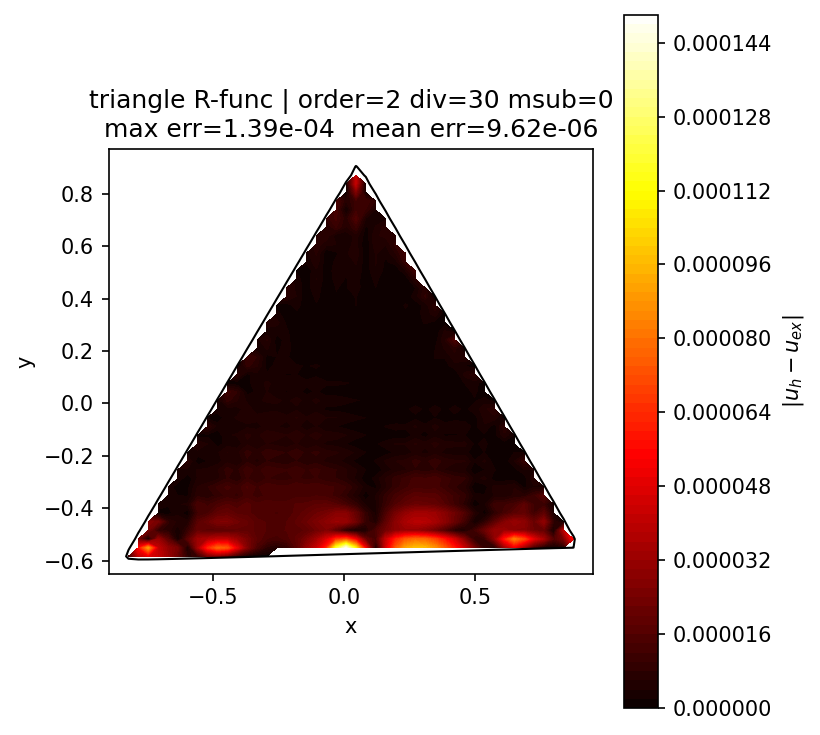

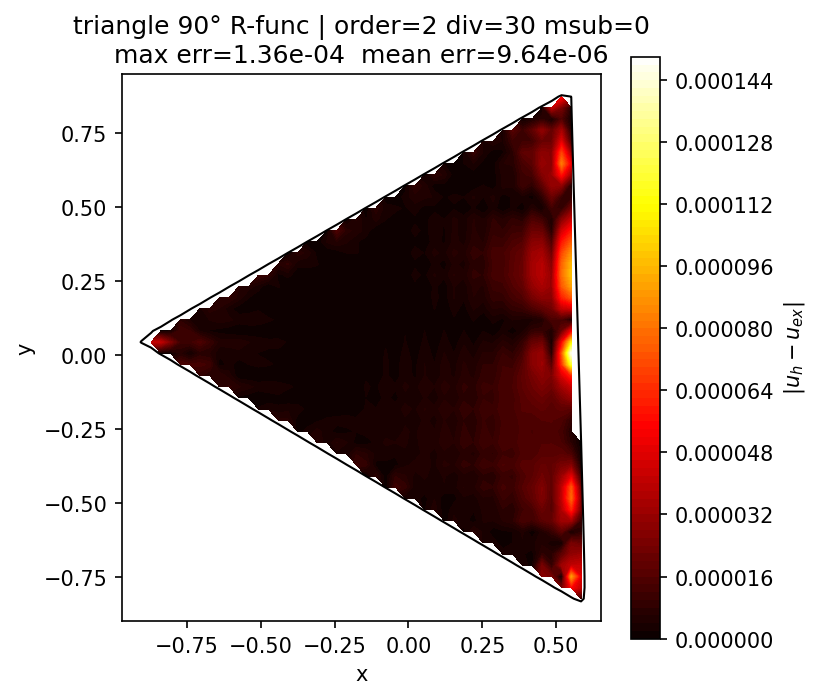

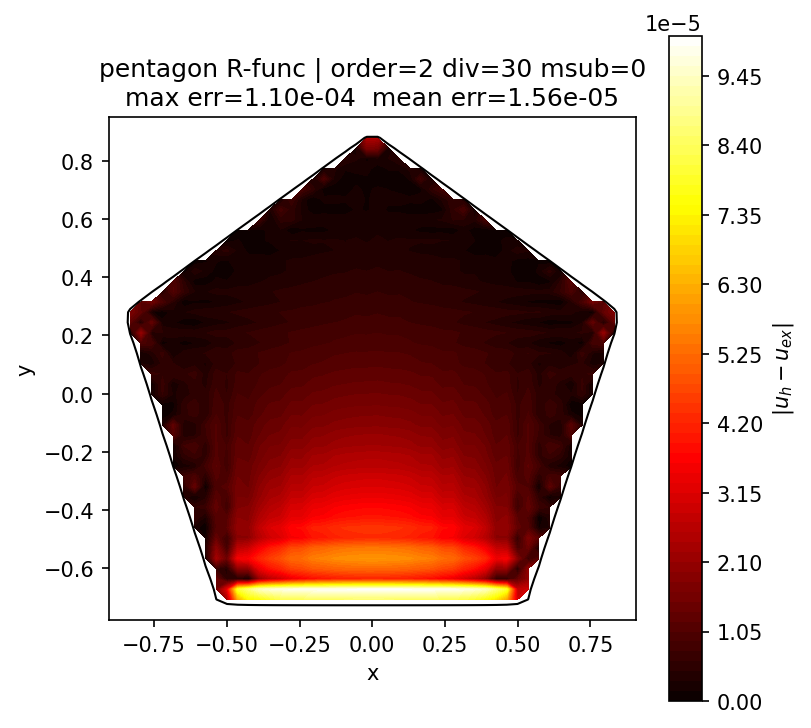

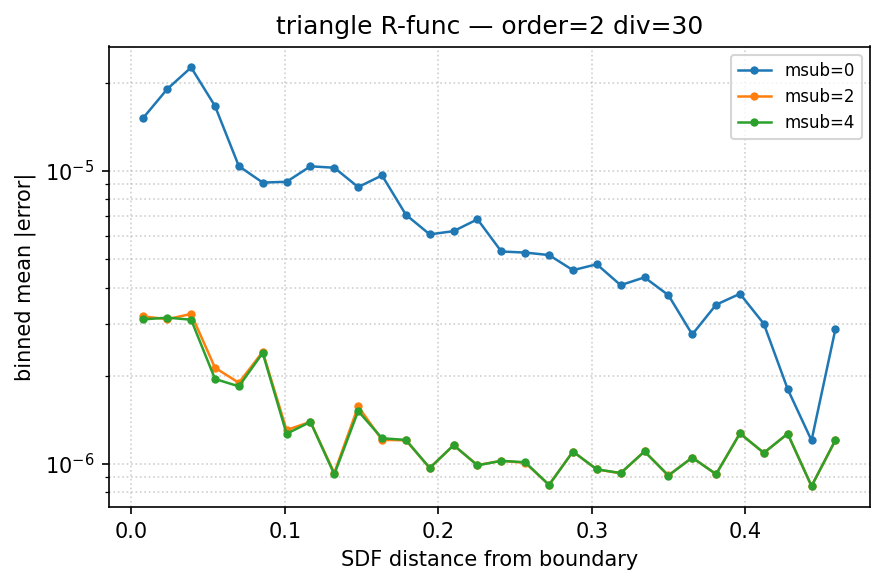

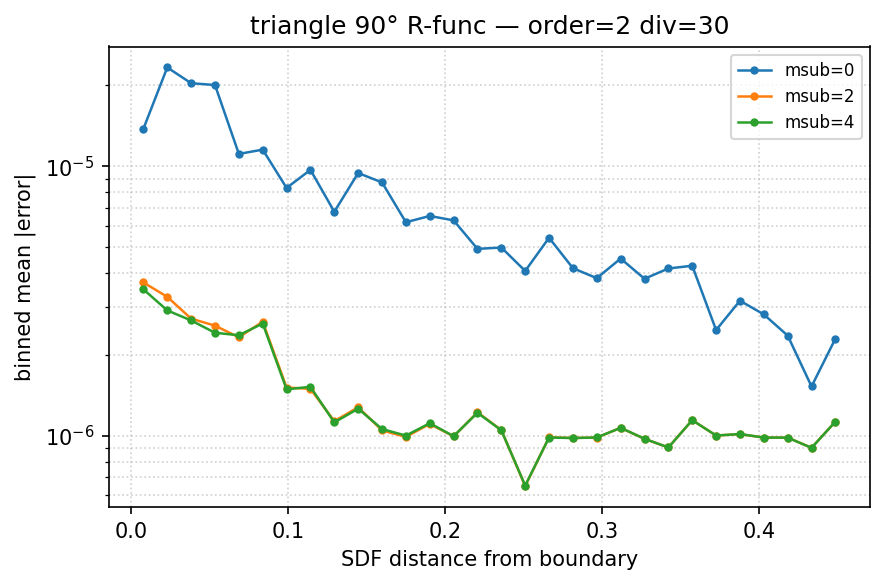

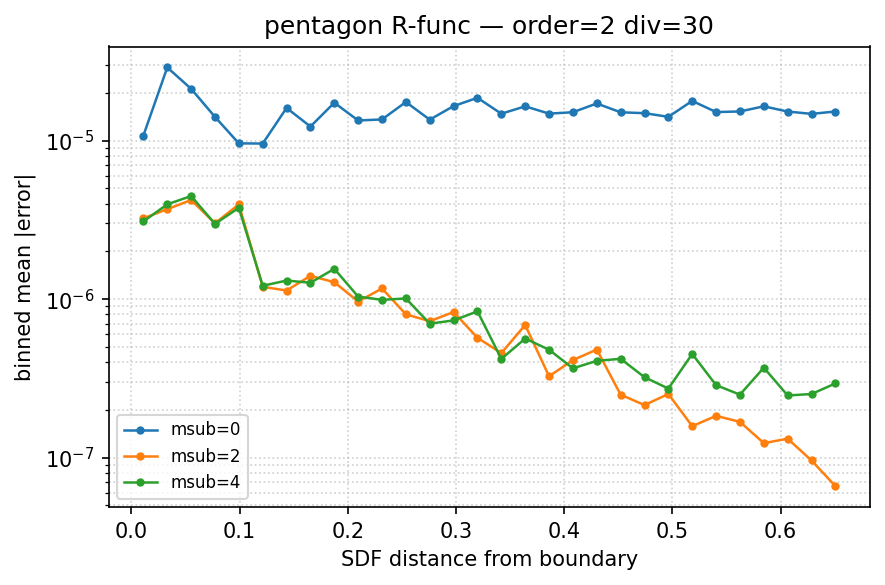

In [4]:
# --------------- Error heatmaps (first config per geometry) ---------------
deg_show = DEGREES[0]
div_show = DIVISIONS_LIST[0]
msub_show = MAX_SUBDIVISIONS[0]

for gv in GEOMS:
    key = (gv.name, deg_show, div_show, msub_show)
    res = all_results[key]
    hm = res.get("heatmap")
    if hm is None:
        print(f"No heatmap data for {gv.name}")
        continue

    HX, HY = hm["HX"], hm["HY"]
    HU, HUex = hm["HU"], hm["HUex"]
    err_hm = np.abs(HU - HUex)
    valid = np.isfinite(HU)
    err_plot = np.ma.masked_where(~valid, err_hm)

    fig, ax = plt.subplots(figsize=(5.5, 5))
    im = ax.contourf(HX, HY, err_plot, levels=CONTOUR_LEVELS, cmap="hot")
    fig.colorbar(im, ax=ax, label=r"$|u_h - u_{ex}|$")

    # Draw weight=0 boundary
    with torch.no_grad():
        crd_hm = torch.tensor(np.stack([HX, HY], axis=-1), dtype=torch.float64)
        w_hm = gv.model(crd_hm).numpy()
    ax.contour(HX, HY, w_hm, levels=[0.0], colors="k", linewidths=1.0)

    ax.set_aspect("equal")
    s = res["summary"]
    ax.set_title(
        f"{gv.name} | order={deg_show} div={div_show} msub={msub_show}\n"
        f"max err={s['err_max']:.2e}  mean err={s['err_mean']:.2e}"
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.tight_layout()
    plt.show()


# --------------- Near-boundary binned error curves ---------------
# Compare MAX_SUBDIVISION=0 vs 2 for the first degree and division count.
for gv in GEOMS:
    bin_dfs, labels = [], []
    for msub in MAX_SUBDIVISIONS:
        key = (gv.name, deg_show, div_show, msub)
        res = all_results.get(key)
        if res is None:
            continue
        bin_dfs.append(res["bins"])
        labels.append(f"msub={msub}")

    if not bin_dfs:
        continue

    fig, ax = plt.subplots(figsize=(6, 4))
    for df, lab in zip(bin_dfs, labels):
        if df.empty:
            continue
        ax.plot(df["sdf_mid"], df["err_mean"], marker="o", ms=3, lw=1.2, label=lab)
    ax.set_yscale("log")
    ax.set_xlabel("SDF distance from boundary")
    ax.set_ylabel("binned mean |error|")
    ax.set_title(f"{gv.name} \u2014 order={deg_show} div={div_show}")
    ax.legend(fontsize=8)
    ax.grid(True, which="both", ls=":", alpha=0.6)
    fig.tight_layout()
    plt.show()

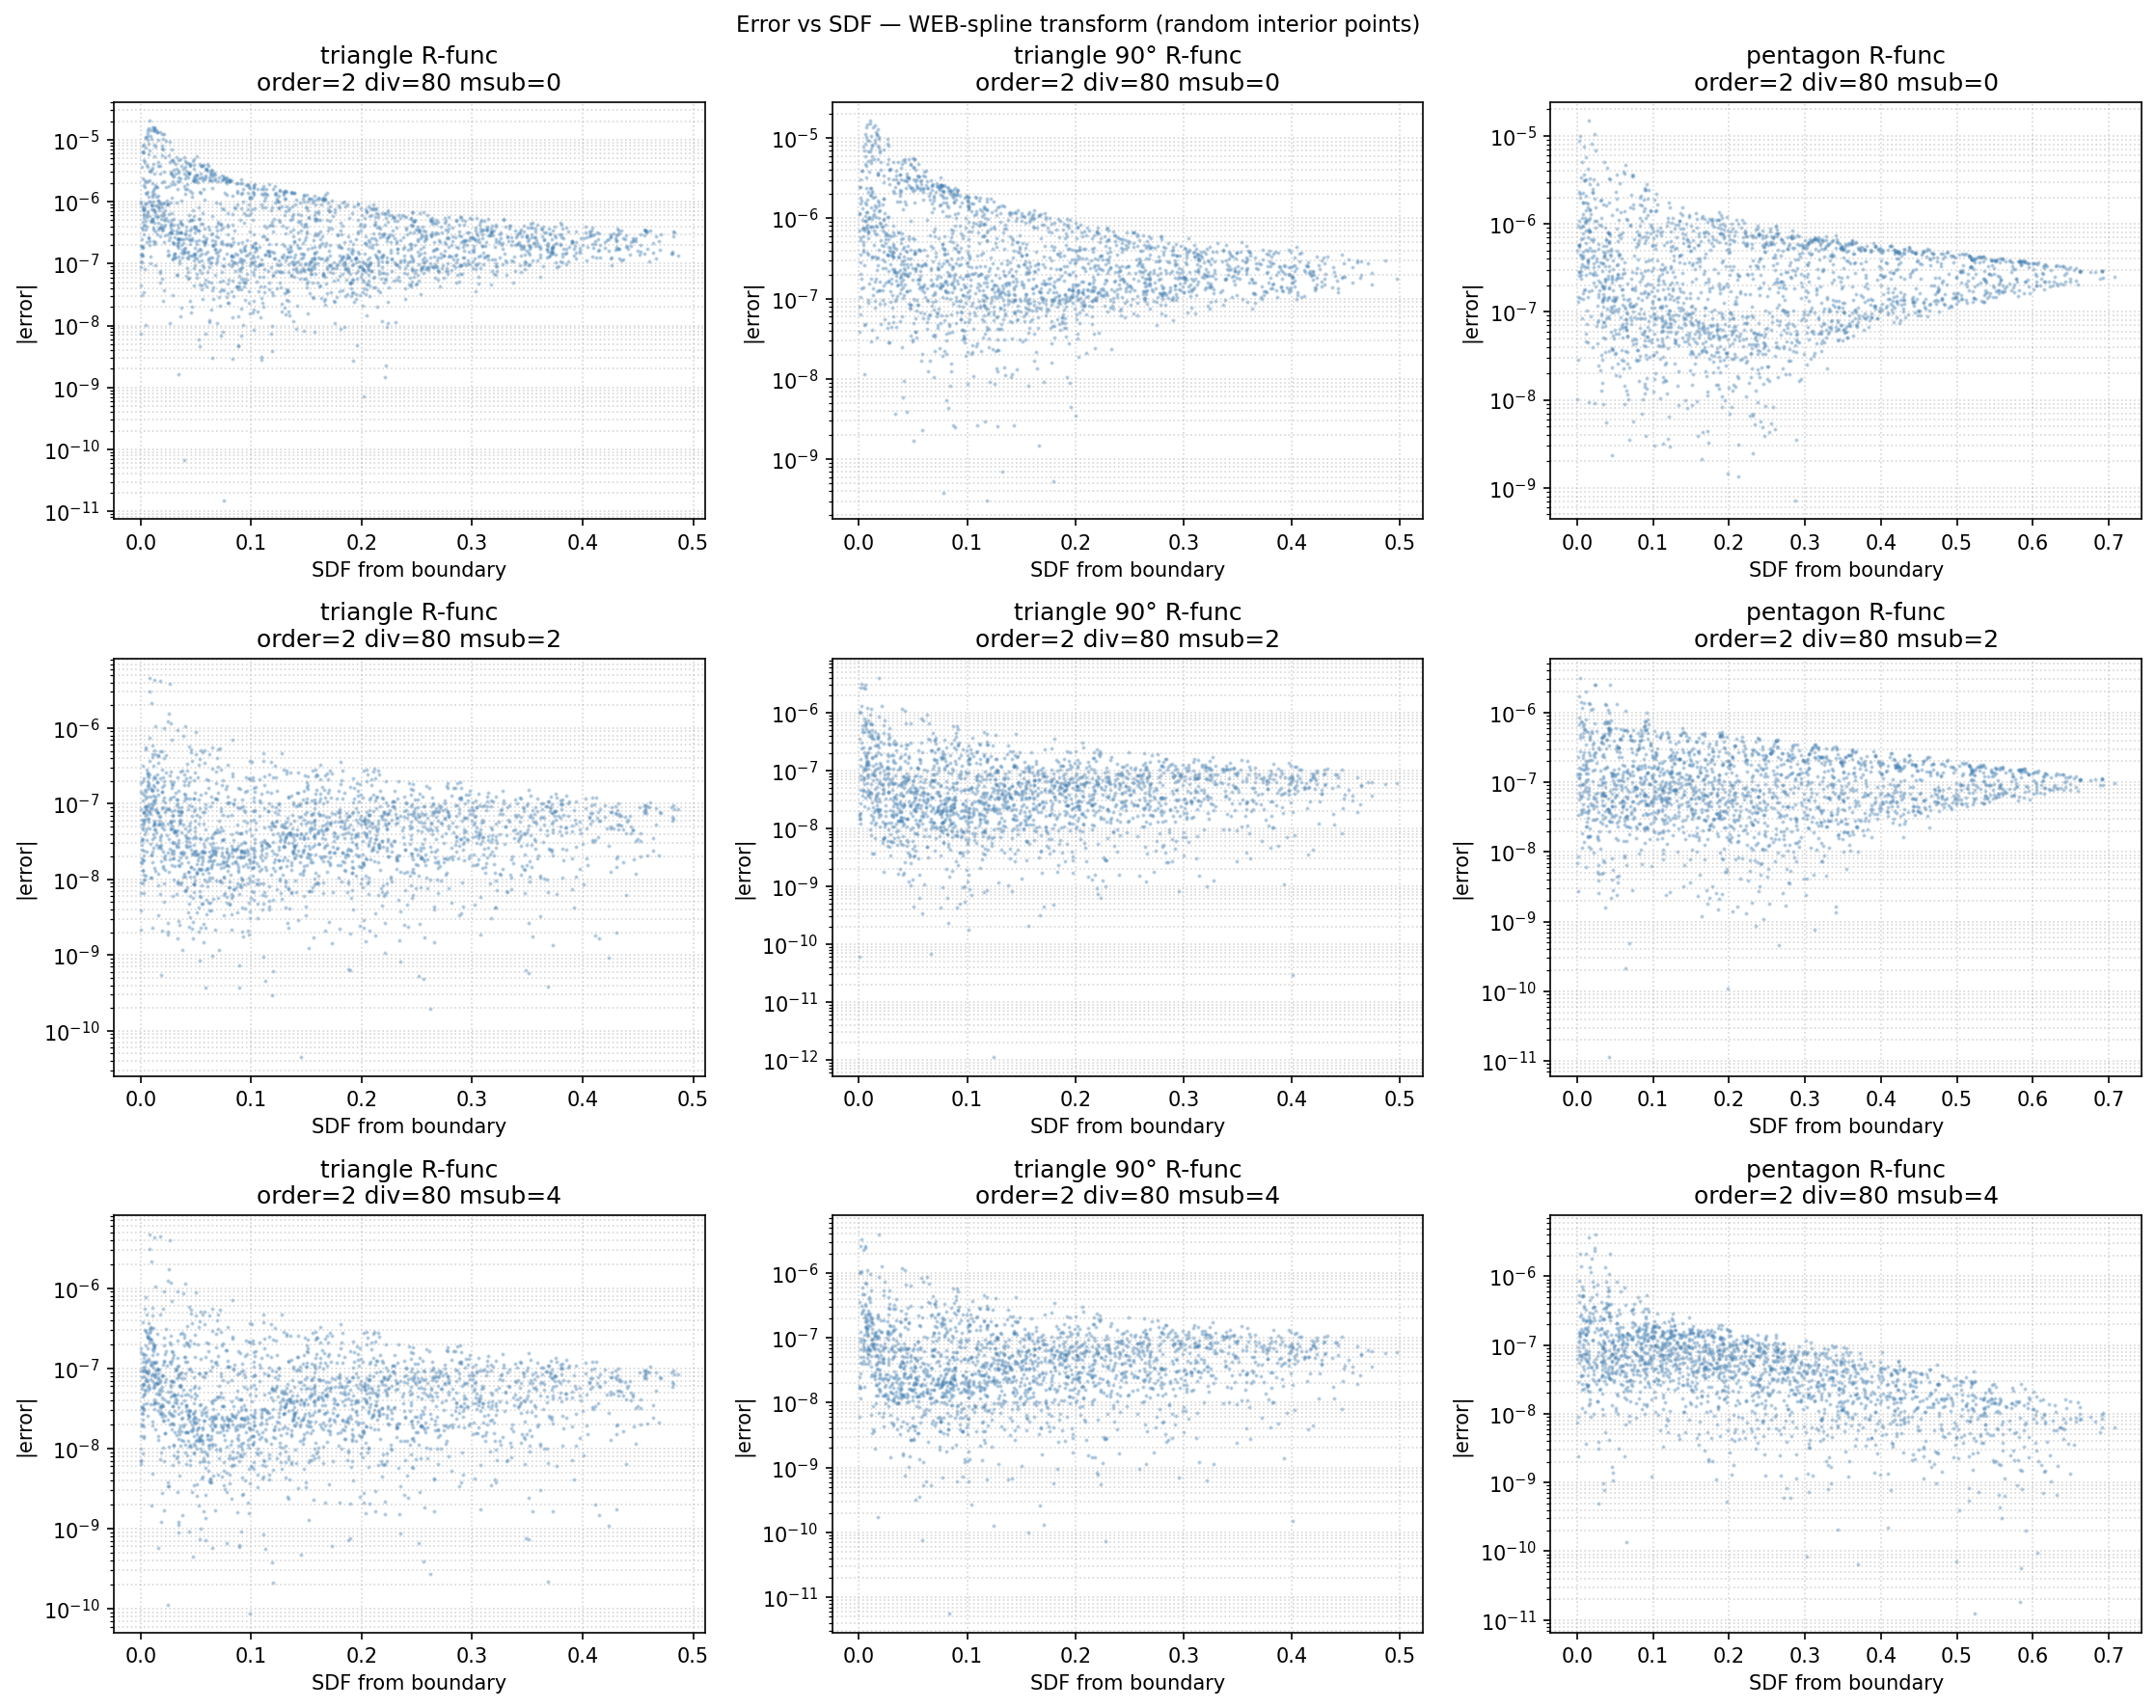

In [18]:
# --------------- Scatter: error vs SDF ---------------
deg_show_s = DEGREES[0]
div_show_s = DIVISIONS_LIST[-1]  # largest mesh for densest domain coverage

fig, axes = plt.subplots(
    len(MAX_SUBDIVISIONS), len(GEOMS),
    figsize=(5 * len(GEOMS), 4 * len(MAX_SUBDIVISIONS)),
    squeeze=False,
)

for row, msub in enumerate(MAX_SUBDIVISIONS):
    for col, gv in enumerate(GEOMS):
        ax = axes[row, col]
        key = (gv.name, deg_show_s, div_show_s, msub)
        res = all_results.get(key)
        if res is None:
            ax.text(0.5, 0.5, "no data", ha="center", va="center")
            continue

        sdf_v = res["sdf"]
        err_v = res["err"]
        valid = np.isfinite(err_v) & (sdf_v > 0)
        ax.scatter(
            sdf_v[valid], err_v[valid],
            s=1, alpha=0.3, c="steelblue", rasterized=True,
        )
        ax.set_yscale("log")
        ax.set_xlabel("SDF from boundary")
        ax.set_ylabel("|error|")
        ax.set_title(
            f"{gv.name}\norder={deg_show_s} div={div_show_s} msub={msub}"
        )
        ax.grid(True, which="both", ls=":", alpha=0.5)

fig.suptitle(
    "Error vs SDF \u2014 WEB-spline transform (random interior points)",
    fontsize=11,
)
fig.tight_layout()
plt.show()

In [6]:
# --------------- Convergence summary tables ---------------
for msub in MAX_SUBDIVISIONS:
    df_sub = summary_df[summary_df["max_subdiv"] == msub]

    pivot_max = df_sub.pivot_table(
        index="geom", columns=["order", "div"], values="err_max"
    )
    pivot_mean = df_sub.pivot_table(
        index="geom", columns=["order", "div"], values="err_mean"
    )

    print(f"\n{'='*60}")
    print(f"MAX_SUBDIVISION = {msub}")
    print(f"{'='*60}")

    print("\nMax error (random interior points):")
    display(pivot_max)

    print("\nMean error (random interior points):")
    display(pivot_mean)


MAX_SUBDIVISION = 0

Max error (random interior points):


order                       2                             3            \
div                        30        50        80        30        50   
geom                                                                    
pentagon R-func      0.000110  0.000022  0.000015  0.000158  0.000025   
triangle 90° R-func  0.000136  0.000042  0.000016  0.000129  0.000032   
triangle R-func      0.000139  0.000039  0.000020  0.000130  0.000042   

order                          
div                        80  
geom                           
pentagon R-func      0.000006  
triangle 90° R-func  0.000018  
triangle R-func      0.000013


Mean error (random interior points):


order                       2                                     3  \
div                        30            50            80        30   
geom                                                                  
pentagon R-func      0.000016  6.906945e-07  4.060498e-07  0.000024   
triangle 90° R-func  0.000010  2.466805e-06  7.225699e-07  0.000005   
triangle R-func      0.000010  2.501319e-06  7.466014e-07  0.000004   

order                                            
div                            50            80  
geom                                             
pentagon R-func      5.696096e-07  7.561828e-07  
triangle 90° R-func  1.082559e-06  3.473926e-07  
triangle R-func      1.179571e-06  3.600888e-07


MAX_SUBDIVISION = 2

Max error (random interior points):


...

order                       2                                         3  \
div                        30            50            80            30   
geom                                                                      
pentagon R-func      0.000002  5.312155e-07  1.443076e-07  2.551740e-07   
triangle 90° R-func  0.000002  3.264391e-07  8.367525e-08  3.324959e-07   
triangle R-func      0.000002  3.278095e-07  8.165281e-08  3.319467e-07   

order                                            
div                            50            80  
geom                                             
pentagon R-func      1.785273e-07  6.196388e-08  
triangle 90° R-func  5.303604e-08  1.411483e-08  
triangle R-func      4.726727e-08  1.366029e-08


MAX_SUBDIVISION = 4

Max error (random interior points):


order                       2                             3            \
div                        30        50        80        30        50   
geom                                                                    
pentagon R-func      0.000030  0.000021  0.000004  0.000008  0.000023   
triangle 90° R-func  0.000037  0.000009  0.000004  0.000028  0.000004   
triangle R-func      0.000050  0.000014  0.000005  0.000039  0.000003   

order                          
div                        80  
geom                           
pentagon R-func      0.000001  
triangle 90° R-func  0.000002  
triangle R-func      0.000007


Mean error (random interior points):


order                       2                                         3  \
div                        30            50            80            30   
geom                                                                      
pentagon R-func      0.000002  4.389432e-07  7.920735e-08  2.590581e-07   
triangle 90° R-func  0.000002  3.165715e-07  7.843652e-08  3.005014e-07   
triangle R-func      0.000002  3.148432e-07  8.070565e-08  3.029445e-07   

order                                            
div                            50            80  
geom                                             
pentagon R-func      1.372157e-07  8.654251e-09  
triangle 90° R-func  4.208861e-08  1.154623e-08  
triangle R-func      3.634082e-08  1.083415e-08

# Neural enhancement

In [1]:
import network_defs as net
torch.set_default_dtype(torch.float64)

import importlib
importlib.reload(FEM_WEB)
importlib.reload(net)

# ---- Configuration ----
NUM_EPOCHS = 1000
BATCH_SIZE = 1000          # batch per epoch (subsampled from pre-computed pool)
POOL_SIZE = 10000         # total near-boundary points (FEM evaluated once)
EPS_BAND = 0.12           # SDF bandwidth: only sample points with 0 < SDF < EPS_BAND
CUTOFF_SIGMA = 0.04       # Gaussian cutoff width applied to w (R-function weight)
DOWNSCALE = 1

deg_show_s = DEGREES[0]
div_show_s = DIVISIONS_LIST[-1]
name = "triangle R-func"
msub = MAX_SUBDIVISIONS[-1]
key = (name, deg_show_s, div_show_s, msub)
res = all_results.get(key)
ss = res["sol_state"]

# Restore FEM globals for this geometry
FEM.set_function_case(9)
FEM.ACTIVE_MODEL = ss["model"]
mesh.TRANSFORM = None

# Reinitialize SIREN model + optimizer
model_triangle = net.Sirexp(
    architecture=[3, 256, 256, 256, 1], outermost_linear=True,
    first_omega_0=60.0, hidden_omega_0=60.0
).double()
optimizer = torch.optim.Adam(model_triangle.parameters(), lr=1e-6)

# Precompute triangle vertices as tensor (constant)
TRI_VERTS_T = torch.tensor(TRI_VERTS, dtype=torch.float64)

def compute_edge_distances(crd, verts_t):
    """Signed halfplane distances: crd -> dists (differentiable w.r.t. crd)."""
    hp = geom._halfplane_distances(crd, verts_t)
    return torch.stack(hp, dim=-1)  # (N, 3)

def sample_near_boundary_points(verts_np, n_points, eps_band, rng=None):
    """Rejection-sample points inside the triangle with SDF < eps_band."""
    if rng is None:
        rng = np.random.default_rng(42)
    xmin, xmax = float(verts_np[:, 0].min()), float(verts_np[:, 0].max())
    ymin, ymax = float(verts_np[:, 1].min()), float(verts_np[:, 1].max())
    pts_x, pts_y = [], []
    collected = 0
    while collected < n_points:
        batch = max(n_points * 5, 10000)
        rx = rng.uniform(xmin, xmax, size=batch)
        ry = rng.uniform(ymin, ymax, size=batch)
        crd = torch.tensor(np.stack([rx, ry], axis=-1), dtype=torch.float64)
        verts_t = crd.new_tensor(verts_np)
        # True SDF (positive inside)
        sdf = geom.convex_polygon_sdf(crd, verts_t).numpy()
        mask = (sdf > 0) & (sdf < eps_band)
        pts_x.append(rx[mask])
        pts_y.append(ry[mask])
        collected += mask.sum()
    pts_x = np.concatenate(pts_x)[:n_points]
    pts_y = np.concatenate(pts_y)[:n_points]
    return pts_x, pts_y

NameError: name 'torch' is not defined

In [81]:

# ==========================================================================
# PRE-COMPUTE FEM quantities once on a fixed pool of near-boundary points
# ==========================================================================
print(f"Sampling {POOL_SIZE} near-boundary points (SDF < {EPS_BAND})...")
t0 = time.time()
pool_x, pool_y = sample_near_boundary_points(TRI_VERTS, POOL_SIZE, EPS_BAND)
print(f"  Sampling done in {time.time()-t0:.1f}s")

print(f"Pre-computing FEM Hessian on {POOL_SIZE} points (one-time cost)...")
t0 = time.time()
_, _, _, pool_uxx_fem, pool_uyy_fem = FEM_WEB.reconstructSolutionHessianDiag(
    pool_x, pool_y, ss["u_reduced"],
    ss["model"], ss["p"], ss["q"], ss["knotvector_u"], ss["knotvector_w"],
    ss["bsp_class"], ss["ext_basis"])
print(f"  FEM Hessian done in {time.time()-t0:.1f}s")

print("Pre-computing weight function w and derivatives...")
t0 = time.time()
pool_w, pool_wx, pool_wy, pool_wxx, pool_wyy = FEM._eval_weight_and_hessian_diag_np(
    pool_x, pool_y, ss["model"], transform=None)
print(f"  Weight derivatives done in {time.time()-t0:.1f}s")

# Load function f at pool points
pool_f = -(2.0 * (pool_wx**2 + pool_wy**2) + 2.0 * pool_w * (pool_wxx + pool_wyy))
# FEM PDE residual at pool points
pool_fem_residual = pool_uxx_fem + pool_uyy_fem + pool_f

# Flatten all pool arrays
pool_w = pool_w.ravel()
pool_wx = pool_wx.ravel()
pool_wy = pool_wy.ravel()
pool_wxx = pool_wxx.ravel()
pool_wyy = pool_wyy.ravel()
pool_fem_residual = pool_fem_residual.ravel()

# ==========================================================================
# PRE-COMPUTE cutoff phi(w) and combined weight psi = phi * w
# ==========================================================================
# The cutoff phi is defined as a function of the *smooth* R-function weight w
# (not the non-differentiable true SDF). This avoids differentiability issues.
#
# phi(w) = exp(-w^2 / (2*sigma^2))
# phi'(w)  = -w/sigma^2 * phi
# phi''(w) = (-1/sigma^2 + w^2/sigma^4) * phi
#
# Combined weight:  psi = phi * w
# Spatial derivatives via chain rule + product rule:
#   psi_x  = phi_x * w  + phi * w_x
#   psi_xx = phi_xx * w + 2*phi_x*w_x + phi * w_xx
#   (and analogously for y)
print("Pre-computing cutoff phi(w) and combined weight psi = phi*w ...")
s2 = CUTOFF_SIGMA ** 2

pool_phi = np.exp(-pool_w**2 / (2.0 * s2))
phi_prime = -pool_w / s2 * pool_phi            # d(phi)/d(w)
phi_double_prime = (-1.0/s2 + pool_w**2/s2**2) * pool_phi  # d^2(phi)/d(w)^2

# Spatial derivatives of phi via chain rule: phi_x = phi'(w) * w_x
pool_phi_x = phi_prime * pool_wx
pool_phi_y = phi_prime * pool_wy
# phi_xx = phi''(w) * w_x^2 + phi'(w) * w_xx
pool_phi_xx = phi_double_prime * pool_wx**2 + phi_prime * pool_wxx
pool_phi_yy = phi_double_prime * pool_wy**2 + phi_prime * pool_wyy

# Combined weight psi = phi * w
pool_psi = pool_phi * pool_w
pool_psi_x = pool_phi_x * pool_w + pool_phi * pool_wx
pool_psi_y = pool_phi_y * pool_w + pool_phi * pool_wy
pool_psi_xx = pool_phi_xx * pool_w + 2.0 * pool_phi_x * pool_wx + pool_phi * pool_wxx
pool_psi_yy = pool_phi_yy * pool_w + 2.0 * pool_phi_y * pool_wy + pool_phi * pool_wyy

print(f"  Cutoff sigma={CUTOFF_SIGMA}, phi range [{pool_phi.min():.4f}, {pool_phi.max():.4f}]")
print(f"  psi range [{pool_psi.min():.6f}, {pool_psi.max():.6f}]")

print(f"\nPool ready: {POOL_SIZE} near-boundary points")
print(f"Starting training: {NUM_EPOCHS} epochs, batch_size={BATCH_SIZE}")


Sampling 10000 near-boundary points (SDF < 0.12)...
  Sampling done in 0.1s
Pre-computing FEM Hessian on 10000 points (one-time cost)...
  FEM Hessian done in 119.9s
Pre-computing weight function w and derivatives...
  Weight derivatives done in 0.0s
Pre-computing cutoff phi(w) and combined weight psi = phi*w ...
  Cutoff sigma=0.04, phi range [0.0374, 1.0000]
  psi range [0.000039, 0.024261]

Pool ready: 10000 near-boundary points
Starting training: 1000 epochs, batch_size=1000


epoch    0  loss=1.098366e-03
epoch   50  loss=1.944620e-03
epoch  100  loss=2.088972e-03
epoch  150  loss=1.081999e-03
epoch  200  loss=1.848544e-03
epoch  250  loss=1.265927e-03
epoch  300  loss=2.790531e-04
epoch  350  loss=2.713143e-04
epoch  400  loss=2.037240e-04
epoch  450  loss=1.807570e-03
epoch  500  loss=7.888236e-04
epoch  550  loss=1.788950e-03
epoch  600  loss=5.567744e-04
epoch  650  loss=1.179335e-03
epoch  700  loss=7.705756e-04
epoch  750  loss=7.950850e-04
epoch  800  loss=2.402273e-04
epoch  850  loss=4.337597e-04
epoch  900  loss=1.308546e-03
epoch  950  loss=2.692065e-03
epoch  999  loss=2.756360e-03


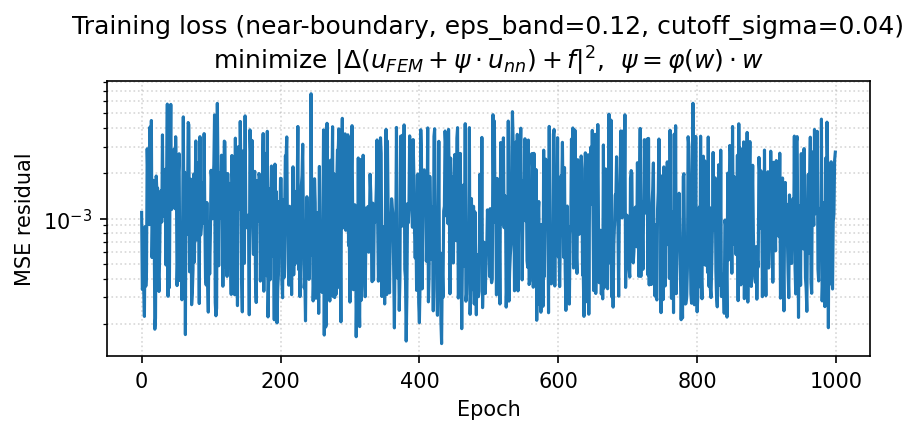

In [78]:

# ==========================================================================
# TRAINING LOOP (no FEM evaluation inside loop — only NN forward + autograd)
# Option 1: Mathematically consistent cutoff.
# Ansatz: u = u_FEM + psi * u_nn   where psi = phi(w) * w
# Loss:   mean( |Δ(u_FEM + psi·u_nn) + f|² )  =  mean( |fem_residual + Δ(psi·u_nn)|² )
# Δ(psi·u_nn) = Δpsi·u_nn + 2(∇psi·∇u_nn) + psi·Δu_nn
# ==========================================================================
loss_history = []
rng_train = np.random.default_rng(123)

for epoch in range(NUM_EPOCHS):
    # Sub-sample a batch from the pre-computed pool
    idx = rng_train.choice(POOL_SIZE, size=BATCH_SIZE, replace=False)

    bx, by = pool_x[idx], pool_y[idx]
    b_fem_res = pool_fem_residual[idx]
    b_psi = pool_psi[idx]
    b_psi_x = pool_psi_x[idx]
    b_psi_y = pool_psi_y[idx]
    b_psi_xx = pool_psi_xx[idx]
    b_psi_yy = pool_psi_yy[idx]

    # Convert FEM constants to tensors
    fem_residual_t = torch.tensor(b_fem_res, dtype=torch.float64)
    psi_t = torch.tensor(b_psi, dtype=torch.float64)
    psi_x_t = torch.tensor(b_psi_x, dtype=torch.float64)
    psi_y_t = torch.tensor(b_psi_y, dtype=torch.float64)
    psi_xx_t = torch.tensor(b_psi_xx, dtype=torch.float64)
    psi_yy_t = torch.tensor(b_psi_yy, dtype=torch.float64)

    # ---- Neural network part (live tensors for autograd) ----
    crd = torch.tensor(np.stack([bx, by], axis=-1), dtype=torch.float64,
                       requires_grad=True)
    dists = compute_edge_distances(crd, TRI_VERTS_T)
    u_nn = model_triangle(dists).squeeze() * DOWNSCALE

    # First derivatives via autograd
    grad_u_nn = torch.autograd.grad(
        u_nn, crd, grad_outputs=torch.ones_like(u_nn),
        create_graph=True, retain_graph=True
    )[0]
    u_nn_x = grad_u_nn[:, 0]
    u_nn_y = grad_u_nn[:, 1]

    # Second derivatives
    u_nn_xx = torch.autograd.grad(
        u_nn_x, crd, grad_outputs=torch.ones_like(u_nn_x),
        create_graph=True, retain_graph=True
    )[0][:, 0]
    u_nn_yy = torch.autograd.grad(
        u_nn_y, crd, grad_outputs=torch.ones_like(u_nn_y),
        create_graph=True, retain_graph=True
    )[0][:, 1]

    # Laplacian of (psi * u_nn) via product rule:
    # Δ(psi·u_nn) = Δpsi·u_nn + 2(∇psi·∇u_nn) + psi·Δu_nn
    laplacian_psi_u_nn = (
        (psi_xx_t + psi_yy_t) * u_nn
        + 2.0 * (psi_x_t * u_nn_x + psi_y_t * u_nn_y)
        + psi_t * (u_nn_xx + u_nn_yy)
    )

    total_residual = fem_residual_t + laplacian_psi_u_nn
    loss = (total_residual ** 2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_val = loss.item()
    loss_history.append(loss_val)
    if epoch % 50 == 0 or epoch == NUM_EPOCHS - 1:
        print(f"epoch {epoch:4d}  loss={loss_val:.6e}")

# Plot training loss
fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(loss_history)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE residual")
ax.set_title(
    f"Training loss (near-boundary, eps_band={EPS_BAND}, cutoff_sigma={CUTOFF_SIGMA})\n"
    r"minimize $|\Delta(u_{FEM} + \psi \cdot u_{nn}) + f|^2$,  $\psi = \varphi(w) \cdot w$"
)
ax.grid(True, which="both", ls=":", alpha=0.5)
fig.tight_layout()
plt.show()


Sweep config: geom=triangle R-func  order=2  div=80  msub=4
Near-boundary sampling: eps_band=0.12, cutoff_sigma=0.04

FEM only:            err_max=4.652e-06  err_mean=8.071e-08
FEM + psi*u_nn:      err_max=4.650e-06   err_mean=8.052e-08
Improvement:         max err 1.0x  mean err 1.0x


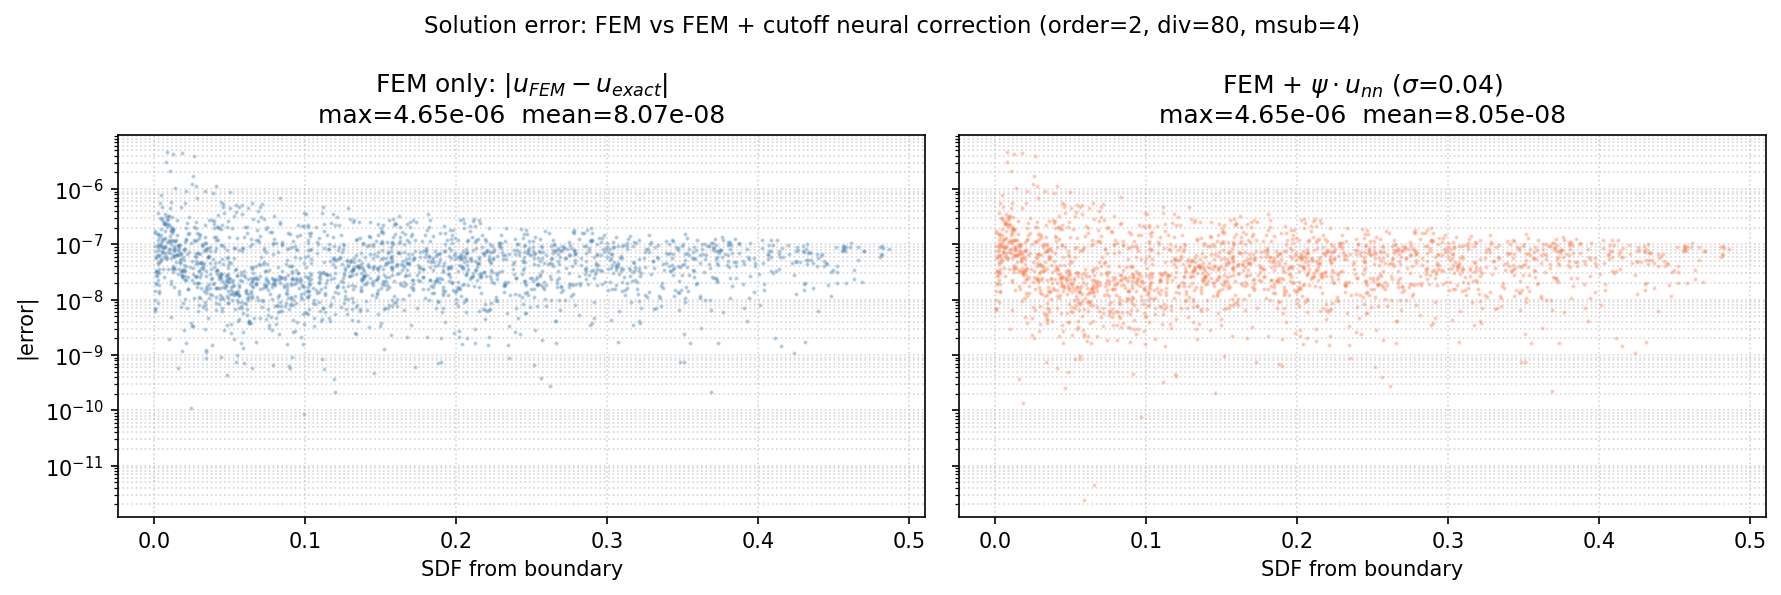

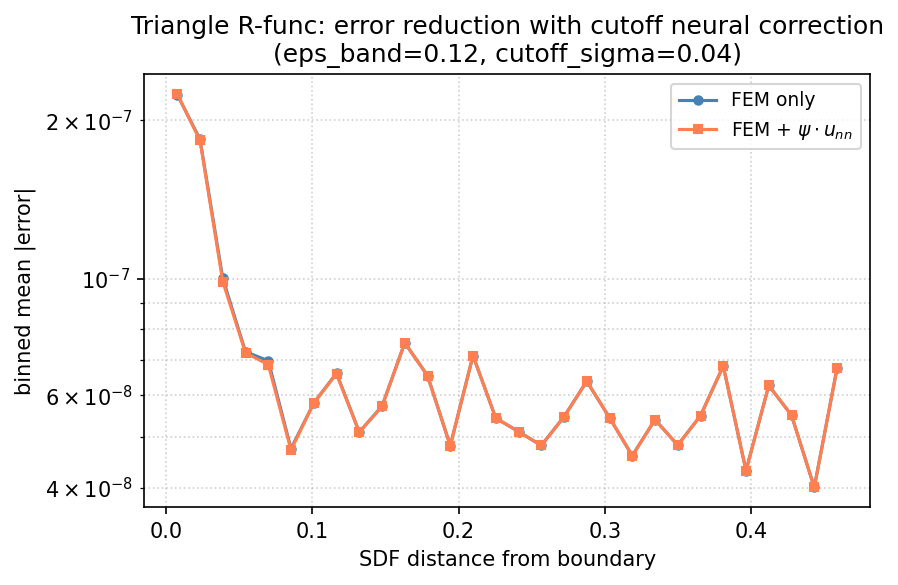

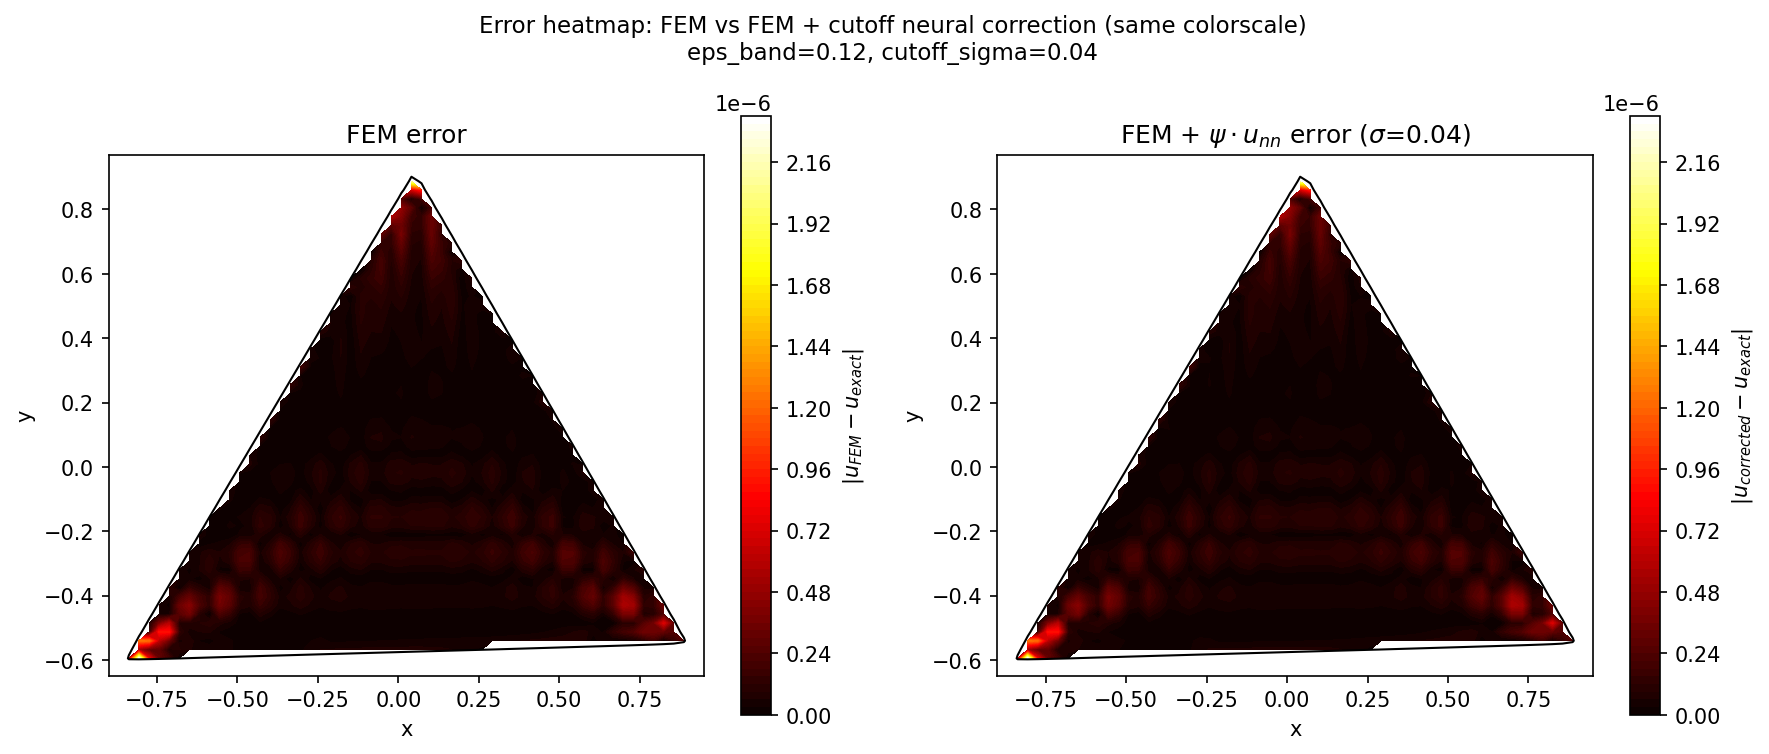

In [79]:
# ---- Evaluate the neural correction: u_corrected = u_FEM + psi * u_nn ----
# Option 1: psi = phi(w) * w, where phi(w) = exp(-w^2 / (2*sigma^2))
# Training and evaluation use the same ansatz (mathematically consistent).
pts_x_plot, pts_y_plot = sample_interior_points(model_triangle, TRI_VERTS, N_RANDOM_EVAL)

# Restore FEM globals
ss = res["sol_state"]
FEM.set_function_case(9)
FEM.ACTIVE_MODEL = ss["model"]
mesh.TRANSFORM = None

# ---- FEM solution at evaluation points ----
u_h = np.zeros(N_RANDOM_EVAL, dtype=np.float64)
for i in range(N_RANDOM_EVAL):
    u_h[i] = FEM_WEB.reconstructSolution(
        pts_x_plot[i], pts_y_plot[i], ss["u_reduced"],
        ss["model"], ss["p"], ss["q"], ss["knotvector_u"], ss["knotvector_w"],
        ss["bsp_class"], ss["ext_basis"])

# ---- Exact solution ----
u_ex = np.array([FEM.solution_function(pts_x_plot[i], pts_y_plot[i])
                 for i in range(N_RANDOM_EVAL)])

# ---- Weight function w at evaluation points ----
w_eval, *_ = FEM._eval_weight_and_hessian_diag_np(
    pts_x_plot, pts_y_plot, ss["model"], transform=None)
w_eval = w_eval.ravel()

# ---- Cutoff phi(w) = exp(-w^2 / (2*sigma^2)) ----
phi_eval = np.exp(-w_eval**2 / (2.0 * CUTOFF_SIGMA**2))
psi_eval = phi_eval * w_eval

# ---- SDF for plotting ----
with torch.no_grad():
    crd_plot = torch.tensor(np.stack([pts_x_plot, pts_y_plot], axis=-1), dtype=torch.float64)
    verts_t = crd_plot.new_tensor(TRI_VERTS)
    sdf_plot = geom.convex_polygon_sdf(crd_plot, verts_t).numpy().ravel()

# ---- Neural network correction at evaluation points ----
dists_plot = compute_edge_distances(crd_plot, TRI_VERTS_T)
with torch.no_grad():
    u_nn_eval = model_triangle(dists_plot).squeeze().numpy()
u_nn_eval = u_nn_eval * DOWNSCALE

# Corrected solution: u = u_FEM + psi * u_nn  (psi = phi * w)
u_corrected = u_h + psi_eval * u_nn_eval

# ---- Errors ----
err_before = np.abs(u_h - u_ex)
err_after = np.abs(u_corrected - u_ex)

sweep_s = res["summary"]
print(f"Sweep config: geom={sweep_s['geom']}  order={sweep_s['order']}  "
      f"div={sweep_s['div']}  msub={sweep_s['max_subdiv']}")
print(f"Near-boundary sampling: eps_band={EPS_BAND}, cutoff_sigma={CUTOFF_SIGMA}")
print(f"\nFEM only:            err_max={err_before.max():.3e}  err_mean={err_before.mean():.3e}")
print(f"FEM + psi*u_nn:      err_max={err_after.max():.3e}   err_mean={err_after.mean():.3e}")
print(f"Improvement:         max err {err_before.max()/max(err_after.max(), 1e-30):.1f}x  "
      f"mean err {err_before.mean()/max(err_after.mean(), 1e-30):.1f}x")

valid = sdf_plot > 0

# ---- Binned error comparison ----
bins_before = compute_near_boundary_binning(sdf_plot, err_before, n_bins=30)
bins_after = compute_near_boundary_binning(sdf_plot, err_after, n_bins=30)

# ---- Plot 1: Scatter — error vs SDF before and after ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax1.scatter(sdf_plot[valid], err_before[valid], s=1, alpha=0.3, c="steelblue", rasterized=True)
ax1.set_yscale("log")
ax1.set_xlabel("SDF from boundary")
ax1.set_ylabel("|error|")
ax1.set_title(f"FEM only: |$u_{{FEM}} - u_{{exact}}$|\n"
              f"max={err_before.max():.2e}  mean={err_before.mean():.2e}")
ax1.grid(True, which="both", ls=":", alpha=0.5)

ax2.scatter(sdf_plot[valid], err_after[valid], s=1, alpha=0.3, c="coral", rasterized=True)
ax2.set_yscale("log")
ax2.set_xlabel("SDF from boundary")
ax2.set_title(r"FEM + $\psi \cdot u_{nn}$" + f" ($\\sigma$={CUTOFF_SIGMA})\n"
              f"max={err_after.max():.2e}  mean={err_after.mean():.2e}")
ax2.grid(True, which="both", ls=":", alpha=0.5)

fig.suptitle(f"Solution error: FEM vs FEM + cutoff neural correction "
             f"(order={sweep_s['order']}, div={sweep_s['div']}, msub={sweep_s['max_subdiv']})",
             fontsize=11)
fig.tight_layout()
plt.show()

# ---- Plot 2: Binned error comparison ----
fig, ax = plt.subplots(figsize=(6, 4))
if not bins_before.empty:
    ax.plot(bins_before["sdf_mid"], bins_before["err_mean"], marker="o", ms=4, lw=1.5,
            label="FEM only", color="steelblue")
if not bins_after.empty:
    ax.plot(bins_after["sdf_mid"], bins_after["err_mean"], marker="s", ms=4, lw=1.5,
            label=r"FEM + $\psi \cdot u_{nn}$", color="coral")
ax.set_yscale("log")
ax.set_xlabel("SDF distance from boundary")
ax.set_ylabel("binned mean |error|")
ax.set_title(f"Triangle R-func: error reduction with cutoff neural correction\n"
             f"(eps_band={EPS_BAND}, cutoff_sigma={CUTOFF_SIGMA})")
ax.legend(fontsize=9)
ax.grid(True, which="both", ls=":", alpha=0.6)
fig.tight_layout()
plt.show()

# ---- Plot 3: Spatial error heatmap before/after ----
verts_np = ss["model"]._vertices_np
xmin_v, xmax_v = float(verts_np[:, 0].min()), float(verts_np[:, 0].max())
ymin_v, ymax_v = float(verts_np[:, 1].min()), float(verts_np[:, 1].max())
HN = 60
hm_x = np.linspace(xmin_v - 0.05, xmax_v + 0.05, HN)
hm_y = np.linspace(ymin_v - 0.05, ymax_v + 0.05, HN)
HX, HY = np.meshgrid(hm_x, hm_y)

HU_fem = np.full_like(HX, np.nan)
HU_corr = np.full_like(HX, np.nan)
HU_ex = np.full_like(HX, np.nan)

for ix in range(HN):
    for iy in range(HN):
        xx, yy = hm_x[ix], hm_y[iy]
        d_val = mesh.distanceFromContur(xx, yy, ss["model"])
        if hasattr(d_val, "item"):
            d_val = d_val.item()
        if d_val >= 0:
            u_fem_pt = FEM_WEB.reconstructSolution(
                xx, yy, ss["u_reduced"], ss["model"], ss["p"], ss["q"],
                ss["knotvector_u"], ss["knotvector_w"], ss["bsp_class"], ss["ext_basis"])
            HU_fem[iy, ix] = u_fem_pt
            HU_ex[iy, ix] = FEM.solution_function(xx, yy)
            # Neural correction: u_corrected = u_FEM + psi * u_nn
            crd_pt = torch.tensor([[xx, yy]], dtype=torch.float64)
            dists_pt = compute_edge_distances(crd_pt, TRI_VERTS_T)
            with torch.no_grad():
                u_nn_pt = model_triangle(dists_pt).item() * DOWNSCALE
            w_pt, *_ = FEM._eval_weight_and_hessian_diag_np(
                np.float64(xx), np.float64(yy), ss["model"], transform=None)
            w_pt = float(w_pt)
            phi_pt = np.exp(-w_pt**2 / (2.0 * CUTOFF_SIGMA**2))
            HU_corr[iy, ix] = u_fem_pt + phi_pt * w_pt * u_nn_pt

err_fem_grid = np.abs(HU_fem - HU_ex)
err_corr_grid = np.abs(HU_corr - HU_ex)
valid_grid = np.isfinite(HU_fem)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

vmax = np.nanmax(err_fem_grid)
im1 = ax1.contourf(HX, HY, np.ma.masked_where(~valid_grid, err_fem_grid),
                    levels=CONTOUR_LEVELS, cmap="hot", vmin=0, vmax=vmax)
fig.colorbar(im1, ax=ax1, label=r"$|u_{FEM} - u_{exact}|$")
ax1.set_title("FEM error")
ax1.set_aspect("equal")

im2 = ax2.contourf(HX, HY, np.ma.masked_where(~valid_grid, err_corr_grid),
                    levels=CONTOUR_LEVELS, cmap="hot", vmin=0, vmax=vmax)
fig.colorbar(im2, ax=ax2, label=r"$|u_{corrected} - u_{exact}|$")
ax2.set_title(r"FEM + $\psi \cdot u_{nn}$ error ($\sigma$=" + f"{CUTOFF_SIGMA})")
ax2.set_aspect("equal")

# Draw boundary on both
with torch.no_grad():
    crd_hm = torch.tensor(np.stack([HX, HY], axis=-1), dtype=torch.float64)
    w_hm = ss["model"](crd_hm).numpy()
for ax in [ax1, ax2]:
    ax.contour(HX, HY, w_hm, levels=[0.0], colors="k", linewidths=1.0)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.suptitle(f"Error heatmap: FEM vs FEM + cutoff neural correction (same colorscale)\n"
             f"eps_band={EPS_BAND}, cutoff_sigma={CUTOFF_SIGMA}", fontsize=11)
fig.tight_layout()
plt.show()
